In [15]:
import numpy as np
import xarray as xr
import pandas as pd
from glob import glob
from scipy.stats import wasserstein_distance

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmcrameri.cm as cm

In [4]:
# Constants

START_DATE = np.datetime64('2000-01-01T00:00:00.000000000')
END_DATE = np.datetime64('2023-09-30T23:00:00.000000000')
# START_DATE = np.datetime64('2000-01-01T00:00:00.000000000')
# END_DATE = np.datetime64('2010-12-31T23:00:00.000000000')
N_HOURS = (END_DATE - START_DATE) / np.timedelta64(1, 'h') + 1
N_DAYS = np.round((END_DATE - START_DATE) / np.timedelta64(1, 'D'))
print(N_HOURS, N_DAYS)

COVERAGE_THRESHOLD = 0.9
ZSCORE_THRESHOLD = 5  # for outlier detection; may want to adjust (this seems to reject some plausible Wind Spd values, for instance)
vars = [
    "Wind Spd (km/h)",
]

BAD_MONTHS = [[2005, 4],
             [2005, 7],
             [2005, 10],
             [2006, 3],
             [2006, 9],
             [2008, 7],
             [2015, 10],
             [2017, 8],
             [2017, 11],
             [2019, 9],
             [2021, 7],
             [2022, 2],
             [2023, 6]]


208176.0 8674.0


In [5]:
def readable_time_coord(ds, time_var='Times'):

    time_vals = ds[time_var].values

    # Extract integer (YYYYMMDD) and fractional day parts
    dates_int = time_vals.astype(int)
    frac_days = time_vals - dates_int

    # Parse integers to datetime
    base_dates = pd.to_datetime(dates_int.astype(str), format="%Y%m%d")

    # Add fractional day as timedelta
    full_times = base_dates + pd.to_timedelta(frac_days, unit="D")
    full_times = full_times.round("1h")

    # Assign back to dataset
    ds = ds.assign_coords({time_var: full_times})
    ds = ds.transpose(time_var, ...)

    ds = ds.rename({time_var: "time"})
    
    return ds

# Find the nearest grid point in winds_ds to the station's lat/lon
def get_nearest_wrf_point(ds, lat, lon):
    abs_lat = np.abs(ds['XLAT'] - lat)
    abs_lon = np.abs(ds['XLONG'] - lon)
    dist = abs_lat + abs_lon
    # Find indices of the minimum distance
    idx = np.unravel_index(np.argmin(dist.values), dist.shape)
    return idx

# Open WRF Data

In [6]:
topography = xr.open_dataset("/users/rpayne/data/topography/hr/HGT_orig.nc")

# DAILY MEAN WINDS

winds_ds = readable_time_coord(xr.open_dataset("/users/rpayne/data/unproc/WRF-UBC/WS10/WS10_dailymean_199910_202309.nc"))
winds_ds = winds_ds.sel(time=slice(START_DATE, END_DATE)).drop_vars('Times_bnds')

winds_ds

<xarray.Dataset> Size: 13GB
Dimensions:  (south_north: 702, west_east: 558, time: 8566)
Coordinates:
    XLONG    (south_north, west_east) float32 2MB ...
    XLAT     (south_north, west_east) float32 2MB ...
  * time     (time) datetime64[ns] 69kB 2000-01-01T12:00:00 ... 2023-09-30T12...
Dimensions without coordinates: south_north, west_east
Data variables:
    WS10     (time, south_north, west_east) float32 13GB ...
Attributes: (12/91)
    CDI:                             Climate Data Interface version 1.9.9rc1 ...
    Conventions:                     CF-1.6
    history:                         Thu Aug 14 11:37:08 2025: cdo daymean -s...
    TITLE:                            OUTPUT FROM WRF V4.4.2 MODEL
    START_DATE:                      1999-10-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        559
    ...                              ...
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2
    frequency:                       day
    CDO:                             Climate Data Operators version 1.9.9rc1 ...

# Open Station Data

In [7]:
# Takes ~5 minutes to run

wx_data_fnames = sorted(glob("/users/rpayne/data/unproc/STN_ECCC/api/hourly/*.csv"))
df = pd.concat(
    (pd.read_csv(f, encoding='latin1', low_memory=False) for f in wx_data_fnames),
    ignore_index=True
)
df['Date/Time (LST)'] = pd.to_datetime(df['Date/Time (LST)'], format='%Y-%m-%d %H:%M:%S')
df = df[df['Date/Time (LST)'] >= START_DATE]  # Filter for data to align w WRF
df = df[df['Date/Time (LST)'] <= END_DATE]
df.set_index('Date/Time (LST)', inplace=True)
df.rename(columns={"Temp (Â°C)": "Temp (°C)"}, inplace=True)
df.rename(columns={"Dew Point Temp (Â°C)": "Dew Point Temp (°C)"}, inplace=True)
df

,Longitude (x),Latitude (y),Station Name,Climate ID,Year,Month,Day,Time (LST),Flag,Temp (°C),...,Visibility Flag,Stn Press (kPa),Stn Press Flag,Hmdx,Hmdx Flag,Wind Chill,Wind Chill Flag,Weather,Precip. Amount (mm),Precip. Amount Flag
Date/Time (LST),,,,,,,,,,,,,,,,,,,,,
2000-01-01 00:00:00,-119.44,49.03,OSOYOOS CS,1125852,2000,1,1,00:00,NaN,-0.4,...,M,NaN,M,NaN,NaN,-4.0,NaN,NaN,NaN,NaN
2000-01-01 01:00:00,-119.44,49.03,OSOYOOS CS,1125852,2000,1,1,01:00,NaN,-0.2,...,M,NaN,M,NaN,NaN,-3.0,NaN,NaN,NaN,NaN
2000-01-01 02:00:00,-119.44,49.03,OSOYOOS CS,1125852,2000,1,1,02:00,NaN,-0.2,...,M,NaN,M,NaN,NaN,-3.0,NaN,NaN,NaN,NaN
2000-01-01 03:00:00,-119.44,49.03,OSOYOOS CS,1125852,2000,1,1,03:00,NaN,-0.2,...,M,NaN,M,NaN,NaN,-3.0,NaN,NaN,NaN,NaN
2000-01-01 04:00:00,-119.44,49.03,OSOYOOS CS,1125852,2000,1,1,04:00,NaN,-0.5,...,M,NaN,M,NaN,NaN,-3.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-30 19:00:00,-119.65,49.56,SUMMERLAND CS,112G8L1,2023,9,30,19:00,NaN,11.9,...,NaN,96.51,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2023-09-30 20:00:00,-119.65,49.56,SUMMERLAND CS,112G8L1,2023,9,30,20:00,NaN,11.4,...,NaN,96.55,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2023-09-30 21:00:00,-119.65,49.56,SUMMERLAND CS,112G8L1,2023,9,30,21:00,NaN,10.8,...,NaN,96.59,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN


In [8]:
# Create a dictionary mapping station name to (lat, lon) from df
stn_latlon = {}
stns = df["Station Name"].unique()
for stn in stns:
    stn_rows = df[df["Station Name"] == stn]
    if not stn_rows.empty:
        lat = stn_rows["Latitude (y)"].iloc[0]
        lon = stn_rows["Longitude (x)"].iloc[0]
        stn_latlon[stn] = (lat, lon)
    else:
        stn_latlon[stn] = (None, None)


def get_stn(stn_name, data=df):
    stn = data[data["Station Name"] == stn_name]
    return stn.sort_index()

In [9]:
# Find all stations that meet the coverage threshold for winds

WS_coverage_dict = {}

for i,stn in enumerate(stns):
    print(f"{i+1}/{len(stns)}")
    
    stn_data = get_stn(stn)

    WS_data = stn_data["Wind Spd (km/h)"].resample('D').max()

    WS_coverage = np.count_nonzero(~np.isnan(WS_data)) / N_DAYS
    if WS_coverage >= COVERAGE_THRESHOLD:
        WS_coverage_dict[stn] = WS_coverage

print(f"Number of stations with adequate Wind Speed coverage: {len(WS_coverage_dict)}")

1/203
2/203
3/203
4/203
5/203
6/203
7/203
8/203
9/203
10/203
11/203
12/203
13/203
14/203
15/203
16/203
17/203
18/203
19/203
20/203
21/203
22/203
23/203
24/203
25/203
26/203
27/203
28/203
29/203
30/203
31/203
32/203
33/203
34/203
35/203
36/203
37/203
38/203
39/203
40/203
41/203
42/203
43/203
44/203
45/203
46/203
47/203
48/203
49/203
50/203
51/203
52/203
53/203
54/203
55/203
56/203
57/203
58/203
59/203
60/203
61/203
62/203
63/203
64/203
65/203
66/203
67/203
68/203
69/203
70/203
71/203
72/203
73/203
74/203
75/203
76/203
77/203
78/203
79/203
80/203
81/203
82/203
83/203
84/203
85/203
86/203
87/203
88/203
89/203
90/203
91/203
92/203
93/203
94/203
95/203
96/203
97/203
98/203
99/203
100/203
101/203
102/203
103/203
104/203
105/203
106/203
107/203
108/203
109/203
110/203
111/203
112/203
113/203
114/203
115/203
116/203
117/203
118/203
119/203
120/203
121/203
122/203
123/203
124/203
125/203
126/203
127/203
128/203
129/203
130/203
131/203
132/203
133/203
134/203
135/203
136/203
137/203
138/203
139/

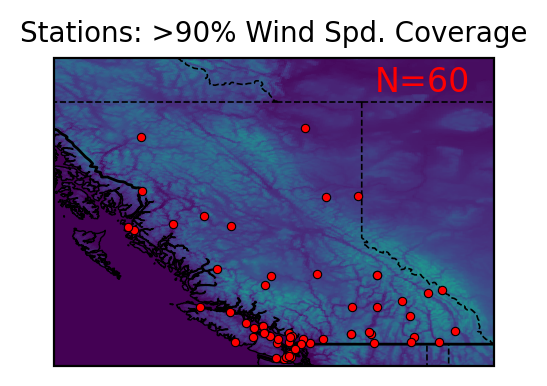

In [10]:
lon = topography['XLONG'].squeeze()
lat = topography['XLAT'].squeeze()
hgt = topography['HGT'].squeeze()

# Create a figure
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()},figsize=(4,2),dpi=200)

# Plot using pcolormesh
mesh = ax.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto')
ax.coastlines(linewidth=0.5,zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=1, zorder=1)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=1)
ax.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=1)
for stn in WS_coverage_dict.keys():
    lat, lon = stn_latlon[stn]
    ax.scatter(lon, lat, marker='.', facecolor='red', edgecolor='k', linewidth=.4, transform=ccrs.PlateCarree())
ax.set_xlim(-134, -114)
ax.set_ylim(48, 62)
ax.text(-119.4, 60.5, f"N={len(WS_coverage_dict.keys())}", fontsize=12, transform=ccrs.PlateCarree(), color='red')

ax.set_title(f"Stations: >{100*COVERAGE_THRESHOLD:.0f}% Wind Spd. Coverage", fontsize=10)
plt.show()

# Create QQ plots

In [11]:
# Create an index for the pd dataframe that ranges over the entire period
# by START_DATE and END_DATE:

full_time_index = pd.Index(
    np.arange(START_DATE, END_DATE + np.timedelta64(1, 'h'), np.timedelta64(1, 'h')),
    name='Date/Time (LST)'
    )

In [12]:
for i, stn in enumerate(sorted(WS_coverage_dict.keys())):

    # Get station data
    print(f"Working on {stn}...")
    
    data = get_stn(stn)
    data = data[~data.index.duplicated(keep='last')]
    data = data.reindex(full_time_index)
    lat = stn_latlon[stn][0]
    lon = stn_latlon[stn][1]
    stn_winds = data["Wind Spd (km/h)"].resample('D').max()
    stn_winds = stn_winds[stn_winds.index < '2023-10-01T00:00:00.000000000']

    for year, month in BAD_MONTHS:
        stn_winds = stn_winds[~((stn_winds.index.year == year) & (stn_winds.index.month == month))]

    # Get model data nearest the station
    nearest_idx = get_nearest_wrf_point(winds_ds, lat, lon)
    wrf_winds = winds_ds.isel(south_north=nearest_idx[0], west_east=nearest_idx[1])

    for year, month in BAD_MONTHS:
        wrf_winds = wrf_winds.sel(time=~((wrf_winds.time.dt.year == year) & (wrf_winds.time.dt.month == month)))

    # turn into numpy arrays, remove points where stn data is NaN, and sort
    a = stn_winds.values
    b = wrf_winds['WS10'].values * 3.6
    try:
        b = np.sort(b[~np.isnan(a)])
        a = np.sort(a[~np.isnan(a)])
    except Exception as e:
        print(f"ERROR WITH STATION {stn}: {e}")
        continue

    # plot
    fig = plt.figure(dpi=150, figsize=(13, 2.5))

    lon = topography['XLONG'].squeeze()
    lat = topography['XLAT'].squeeze()
    hgt = topography['HGT'].squeeze()

    ax0 = fig.add_subplot(1, 3, 1, projection=ccrs.PlateCarree())
    mesh = ax0.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='Greys')
    ax0.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
    provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
        name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
    ax0.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
    lat, lon = stn_latlon[stn]
    ax0.scatter(lon, lat, marker='o', facecolor='red', edgecolor='k', linewidth=.4, transform=ccrs.PlateCarree(), zorder=3)
    ax0.set_xlim(-134, -114)
    ax0.set_ylim(48, 60.5)
    ax0.coastlines(linewidth=0.5, zorder=2)
    ax0.text(-133.5, 58.8, f"{stn}", fontsize=12, transform=ccrs.PlateCarree(), color='red')

    ax1 = fig.add_subplot(1, 3, 2)
    ax1.scatter(a, b, s=20, facecolors='grey', edgecolors='k', marker='o', linewidth=.5, zorder=4)
    ax1.plot([a.min(), a.max()],
            [a.min(), a.max()],
            'k--', lw=.7)
    ax1.set_xlabel("Station Quantile (km/h)", fontsize=7)
    ax1.set_ylabel("WRF Quantile (km/h)", fontsize=7)
    ax1.grid(alpha=.2, ls='--')
    ax1.set_xticks(np.arange(0,a.max()+5,5))
    ax1.set_yticks(np.arange(0,max(a.max(),b.max())+5,5))
    ax1.tick_params(axis='both', which='major', labelsize=5)

    plt.subplots_adjust(wspace=0.15,)
    plt.show()

print("DONE.")

Working on ABBOTSFORD A...


KeyboardInterrupt: 

In [ ]:
wass_dict = {}
corr_dict = {}
rmse_dict = {}

for i, stn in enumerate(WS_coverage_dict.keys()):

    # Get station data
    print(f"Working on {stn}...")

    data = get_stn(stn)
    lat = stn_latlon[stn][0]
    lon = stn_latlon[stn][1]
    start_time = data.index.min().to_datetime64()
    end_time = data.index.max().to_datetime64()
    stn_winds = data["Wind Spd (km/h)"].resample('D').max()
    stn_winds = stn_winds[stn_winds.index < '2023-10-01T00:00:00.000000000']

    for year, month in BAD_MONTHS:
        stn_winds = stn_winds[~((stn_winds.index.year == year) & (stn_winds.index.month == month))]

    # Get model data nearest the station
    nearest_idx = get_nearest_wrf_point(winds_ds, lat, lon)
    wrf_winds = winds_ds.isel(south_north=nearest_idx[0], west_east=nearest_idx[1])

    for year, month in BAD_MONTHS:
        wrf_winds = wrf_winds.sel(time=~((wrf_winds.time.dt.year == year) & (wrf_winds.time.dt.month == month)))

    # turn into numpy arrays, remove points where stn data is NaN, and sort
    a = stn_winds.values
    b = wrf_winds['WS10'].values * 3.6
    try:
        b = b[~np.isnan(a)]
        a = a[~np.isnan(a)]
    except Exception as e:
        print(f"ERROR WITH STATION {stn}: {e}")
        continue

    # calculate correlation coefficient and rmse
    corr_coeff = np.corrcoef(a, b)[0, 1]
    corr_dict[(lat, lon)] = corr_coeff

    rmse = np.sqrt(np.mean((a - b) ** 2))
    rmse_dict[(lat, lon)] = rmse

    # sort and calculate wasserstein distance
    b = np.sort(b)
    a = np.sort(a)
    wasserstein_dist = wasserstein_distance(a, b)
    wass_dict[(lat, lon)] = wasserstein_dist

print("DONE.")

Working on OSOYOOS CS...
Working on PENTICTON A...
Working on PRINCETON A...
Working on KELP REEFS...
Working on RACE ROCKS...
Working on VICTORIA HARBOUR A...
Working on CASTLEGAR A...
Working on VICTORIA GONZALES CS...
Working on CRANBROOK A...
Working on BLUE RIVER A...
Working on KAMLOOPS A...
Working on GOLDEN A...
Working on REVELSTOKE A...
Working on BALLENAS ISLAND...
Working on CHETWYND A...
Working on DAWSON CREEK A...
Working on CAMPBELL RIVER A...
Working on FORT NELSON A...
Working on COMOX A...
Working on NANAIMO A...
Working on PORT HARDY A...
Working on DISCOVERY ISLAND...
Working on GRIEF POINT...
Working on TOFINO A...
Working on ENTRANCE ISLAND...
Working on FANNY ISLAND...
Working on TATLAYOKO LAKE RCS...
Working on WARFIELD RCS...
ERROR WITH STATION WARFIELD RCS: boolean index did not match indexed array along axis 0; size of axis is 8279 but size of corresponding boolean axis is 7913
Working on POWELL RIVER A...
Working on BELLA COOLA A...
Working on STEWART A...


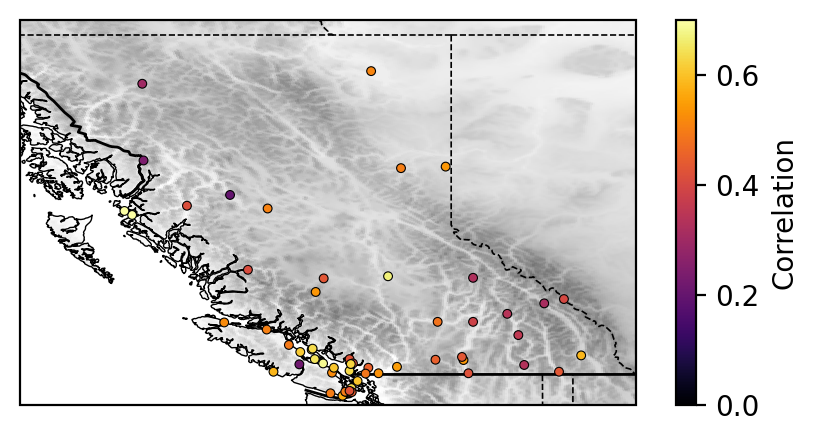

In [ ]:
# plot
fig = plt.figure(dpi=200, figsize=(13, 2.5))

lon = topography['XLONG'].squeeze()
lat = topography['XLAT'].squeeze()
hgt = topography['HGT'].squeeze()

ax0 = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
mesh = ax0.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax0.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax0.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
lat, lon = stn_latlon[stn]
ax0.set_xlim(-134, -114)
ax0.set_ylim(48, 60.5)
ax0.coastlines(linewidth=0.5, zorder=2)

lons = []
lats = []
corrs = []
for stn_coords, corr in corr_dict.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    corrs.append(corr)

scatter = ax0.scatter(
    lons, lats,
    c=corrs,
    s=10,
    cmap='inferno',
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=0.7
)

cbar = plt.colorbar(scatter, ax=ax0, orientation='vertical', pad=0.02)
cbar.set_label('Correlation')

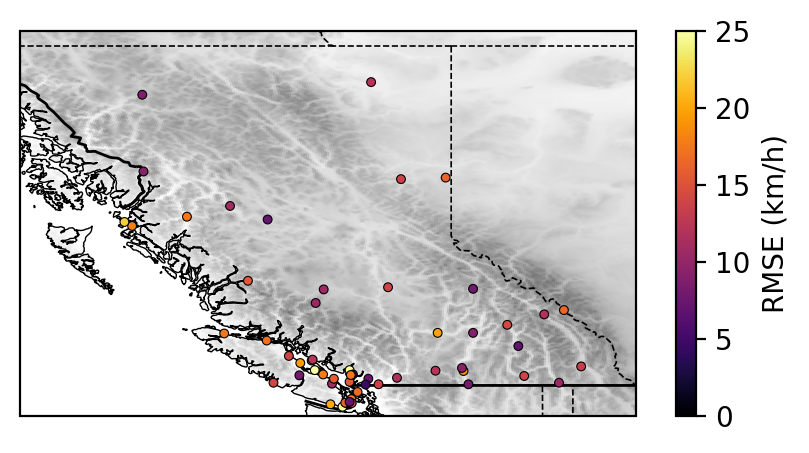

In [ ]:
# plot
fig = plt.figure(dpi=200, figsize=(13, 2.5))

lon = topography['XLONG'].squeeze()
lat = topography['XLAT'].squeeze()
hgt = topography['HGT'].squeeze()

ax0 = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
mesh = ax0.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax0.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax0.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
lat, lon = stn_latlon[stn]
ax0.set_xlim(-134, -114)
ax0.set_ylim(48, 60.5)
ax0.coastlines(linewidth=0.5, zorder=2)

lons = []
lats = []
rmses = []
for stn_coords, rmse in rmse_dict.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    rmses.append(rmse)

scatter = ax0.scatter(
    lons, lats,
    c=rmses,
    s=10,
    cmap='inferno',
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=25,
)

cbar = plt.colorbar(scatter, ax=ax0, orientation='vertical', pad=0.02)
cbar.set_label('RMSE (km/h)')

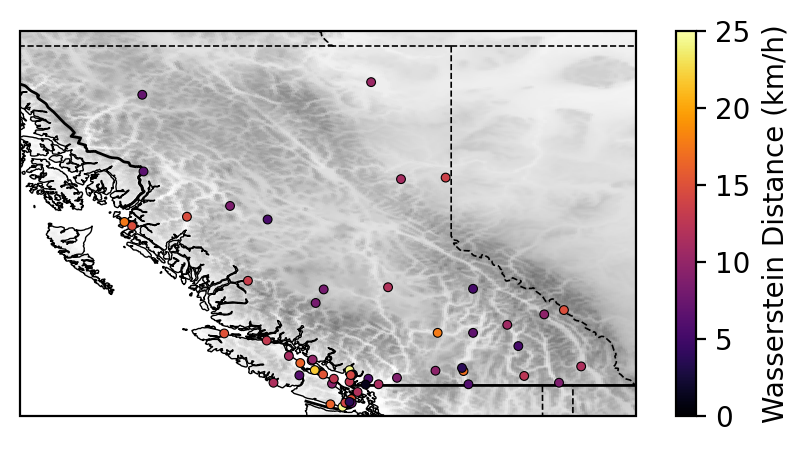

In [ ]:
# plot
fig = plt.figure(dpi=200, figsize=(13, 2.5))

lon = topography['XLONG'].squeeze()
lat = topography['XLAT'].squeeze()
hgt = topography['HGT'].squeeze()

ax0 = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
mesh = ax0.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax0.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax0.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
lat, lon = stn_latlon[stn]
ax0.set_xlim(-134, -114)
ax0.set_ylim(48, 60.5)
ax0.coastlines(linewidth=0.5, zorder=2)

lons = []
lats = []
WDs = []
for stn_coords, wass in wass_dict.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    WDs.append(wass)

scatter = ax0.scatter(
    lons, lats,
    c=WDs,
    s=10,
    cmap='inferno',
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=25
)

cbar = plt.colorbar(scatter, ax=ax0, orientation='vertical', pad=0.02)
cbar.set_label('Wasserstein Distance (km/h)')

In [13]:
# SEASONAL CORRELATIONS

corr_dict_DJF = {}
corr_dict_MAM = {}
corr_dict_JJA = {}
corr_dict_SON = {}
rmse_dict_DJF = {}
rmse_dict_MAM = {}
rmse_dict_JJA = {}
rmse_dict_SON = {}
wass_dict_DJF = {}
wass_dict_MAM = {}
wass_dict_JJA = {}
wass_dict_SON = {}

for i, stn in enumerate(WS_coverage_dict.keys()):

    # Get station data
    print(f"Working on {stn}...")

    data = get_stn(stn)
    lat = stn_latlon[stn][0]
    lon = stn_latlon[stn][1]
    start_time = data.index.min().to_datetime64()
    end_time = data.index.max().to_datetime64()
    stn_winds = data["Wind Spd (km/h)"].resample('D').max()
    stn_winds = stn_winds[stn_winds.index < '2023-10-01T00:00:00.000000000']

    for year, month in BAD_MONTHS:
        stn_winds = stn_winds[~((stn_winds.index.year == year) & (stn_winds.index.month == month))]

    stn_winds_DJF = stn_winds[stn_winds.index.month.isin([12, 1, 2])]
    stn_winds_MAM = stn_winds[stn_winds.index.month.isin([3, 4, 5])]
    stn_winds_JJA = stn_winds[stn_winds.index.month.isin([6, 7, 8])]
    stn_winds_SON = stn_winds[stn_winds.index.month.isin([9, 10, 11])]

    # Get model data nearest the station
    nearest_idx = get_nearest_wrf_point(winds_ds, lat, lon)
    wrf_winds = winds_ds.isel(south_north=nearest_idx[0], west_east=nearest_idx[1])

    for year, month in BAD_MONTHS:
        wrf_winds = wrf_winds.sel(time=~((wrf_winds.time.dt.year == year) & (wrf_winds.time.dt.month == month)))
    
    wrf_winds_DJF = wrf_winds.sel(time=wrf_winds.time.dt.month.isin([12, 1, 2]))
    wrf_winds_MAM = wrf_winds.sel(time=wrf_winds.time.dt.month.isin([3, 4, 5]))
    wrf_winds_JJA = wrf_winds.sel(time=wrf_winds.time.dt.month.isin([6, 7, 8]))
    wrf_winds_SON = wrf_winds.sel(time=wrf_winds.time.dt.month.isin([9, 10, 11]))

    # turn into numpy arrays, remove points where stn data is NaN, and sort
    a_DJF = stn_winds_DJF.values
    b_DJF = wrf_winds_DJF['WS10'].values * 3.6
    try:
        b_DJF = b_DJF[~np.isnan(a_DJF)]
        a_DJF = a_DJF[~np.isnan(a_DJF)]
    except Exception as e:
        print(f"DJF: ERROR WITH STATION {stn}: {e}")
        continue
    corr_coeff_DJF = np.corrcoef(a_DJF, b_DJF)[0, 1]
    corr_dict_DJF[(lat, lon)] = corr_coeff_DJF
    rmse_DJF = np.sqrt(np.mean((a_DJF - b_DJF) ** 2))
    rmse_dict_DJF[(lat, lon)] = rmse_DJF
    wass_DJF = wasserstein_distance(a_DJF, b_DJF)
    wass_dict_DJF[(lat, lon)] = wass_DJF

    a_MAM = stn_winds_MAM.values
    b_MAM = wrf_winds_MAM['WS10'].values * 3.6
    try:
        b_MAM = b_MAM[~np.isnan(a_MAM)]
        a_MAM = a_MAM[~np.isnan(a_MAM)]
    except Exception as e:
        print(f"MAM: ERROR WITH STATION {stn}: {e}")
        continue
    corr_coeff_MAM = np.corrcoef(a_MAM, b_MAM)[0, 1]
    corr_dict_MAM[(lat, lon)] = corr_coeff_MAM
    rmse_MAM = np.sqrt(np.mean((a_MAM - b_MAM) ** 2))
    rmse_dict_MAM[(lat, lon)] = rmse_MAM
    wass_MAM = wasserstein_distance(a_MAM, b_MAM)
    wass_dict_MAM[(lat, lon)] = wass_MAM

    a_JJA = stn_winds_JJA.values
    b_JJA = wrf_winds_JJA['WS10'].values * 3.6
    try:
        b_JJA = b_JJA[~np.isnan(a_JJA)]
        a_JJA = a_JJA[~np.isnan(a_JJA)]
    except Exception as e:
        print(f"JJA: ERROR WITH STATION {stn}: {e}")
        continue
    corr_coeff_JJA = np.corrcoef(a_JJA, b_JJA)[0, 1]
    corr_dict_JJA[(lat, lon)] = corr_coeff_JJA
    rmse_JJA = np.sqrt(np.mean((a_JJA - b_JJA) ** 2))
    rmse_dict_JJA[(lat, lon)] = rmse_JJA
    wass_JJA = wasserstein_distance(a_JJA, b_JJA)
    wass_dict_JJA[(lat, lon)] = wass_JJA

    a_SON = stn_winds_SON.values
    b_SON = wrf_winds_SON['WS10'].values * 3.6
    try:
        b_SON = b_SON[~np.isnan(a_SON)]
        a_SON = a_SON[~np.isnan(a_SON)]
    except Exception as e:
        print(f"SON: ERROR WITH STATION {stn}: {e}")
        continue
    corr_coeff_SON = np.corrcoef(a_SON, b_SON)[0, 1]
    corr_dict_SON[(lat, lon)] = corr_coeff_SON
    rmse_SON = np.sqrt(np.mean((a_SON - b_SON) ** 2))
    rmse_dict_SON[(lat, lon)] = rmse_SON
    wass_SON = wasserstein_distance(a_SON, b_SON)
    wass_dict_SON[(lat, lon)] = wass_SON

print("DONE.")

Working on OSOYOOS CS...
Working on PENTICTON A...
Working on PRINCETON A...
Working on KELP REEFS...
Working on RACE ROCKS...
Working on VICTORIA HARBOUR A...
Working on CASTLEGAR A...
Working on VICTORIA GONZALES CS...
Working on CRANBROOK A...
Working on BLUE RIVER A...
Working on KAMLOOPS A...
Working on GOLDEN A...
Working on REVELSTOKE A...
Working on BALLENAS ISLAND...
Working on CHETWYND A...
Working on DAWSON CREEK A...
Working on CAMPBELL RIVER A...
Working on FORT NELSON A...
Working on COMOX A...
Working on NANAIMO A...
Working on PORT HARDY A...
Working on DISCOVERY ISLAND...
Working on GRIEF POINT...
Working on TOFINO A...
Working on ENTRANCE ISLAND...
Working on FANNY ISLAND...
Working on TATLAYOKO LAKE RCS...
Working on WARFIELD RCS...
DJF: ERROR WITH STATION WARFIELD RCS: boolean index did not match indexed array along axis 0; size of axis is 2107 but size of corresponding boolean axis is 2016
Working on POWELL RIVER A...
Working on BELLA COOLA A...
Working on STEWART 

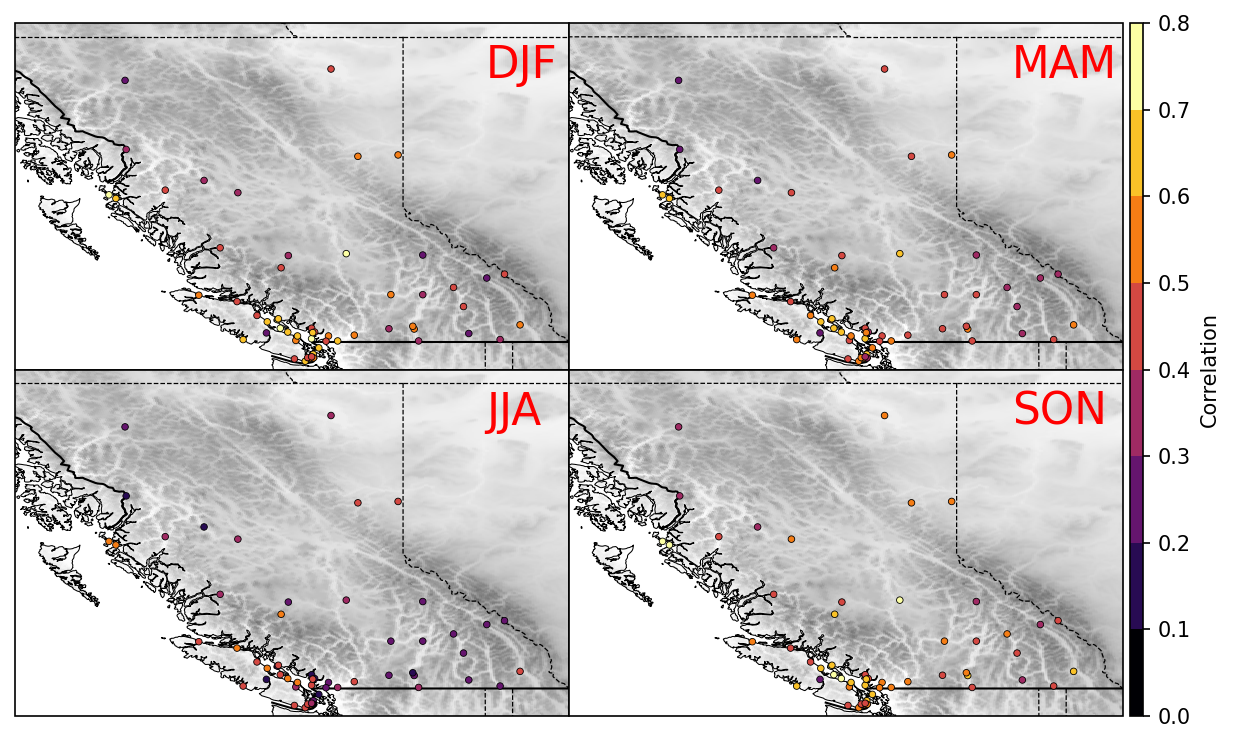

In [16]:
fig = plt.figure(figsize=(11.475,6),dpi=150)

# Create a discrete colormap with 20 steps from inferno
cmap = ListedColormap(plt.cm.inferno(np.linspace(0, 1, 8)))

lon = topography['XLONG'].squeeze()
lat = topography['XLAT'].squeeze()
hgt = topography['HGT'].squeeze()
ax0 = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree())
mesh = ax0.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax0.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax0.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax0.set_xlim(-134, -114)
ax0.set_ylim(48, 60.5)
ax0.coastlines(linewidth=0.5, zorder=2)
ax1 = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree())
mesh = ax1.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax1.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax1.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax1.set_xlim(-134, -114)
ax1.set_ylim(48, 60.5)
ax1.coastlines(linewidth=0.5, zorder=2)
ax2 = fig.add_subplot(2, 2, 3, projection=ccrs.PlateCarree())
mesh = ax2.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax2.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax2.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax2.set_xlim(-134, -114)
ax2.set_ylim(48, 60.5)
ax2.coastlines(linewidth=0.5, zorder=2)
ax3 = fig.add_subplot(2, 2, 4, projection=ccrs.PlateCarree())
mesh = ax3.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax3.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax3.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax3.set_xlim(-134, -114)
ax3.set_ylim(48, 60.5)
ax3.coastlines(linewidth=0.5, zorder=2)

lons, lats, corrs = [], [], []
for stn_coords, corr in corr_dict_DJF.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    corrs.append(corr)
ax0.text(-117, 58.5, "DJF", color='red', fontsize=21)
scatter0 = ax0.scatter(
    lons, lats,
    c=corrs,
    s=10,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=0.8
)
lons, lats, corrs = [], [], []
for stn_coords, corr in corr_dict_MAM.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    corrs.append(corr)
ax1.text(-118, 58.5, "MAM", color='red', fontsize=21)
scatter1 = ax1.scatter(
    lons, lats,
    c=corrs,
    s=10,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=0.8
)
lons, lats, corrs = [], [], []
for stn_coords, corr in corr_dict_JJA.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    corrs.append(corr)
ax2.text(-117, 58.5, "JJA", color='red', fontsize=21)
scatter2 = ax2.scatter(
    lons, lats,
    c=corrs,
    s=10,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=0.8
)
lons, lats, corrs = [], [], []
for stn_coords, corr in corr_dict_SON.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    corrs.append(corr)
ax3.text(-118, 58.5, "SON", color='red', fontsize=21)
scatter3 = ax3.scatter(
    lons, lats,
    c=corrs,
    s=10,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=0.8
)

plt.subplots_adjust(wspace=-.035, hspace=-0)
cbar = plt.colorbar(scatter0, ax=[ax0,ax1,ax2,ax3], orientation='vertical', pad=0.005, shrink=1, aspect=50)
cbar.set_label('Correlation')
plt.show()

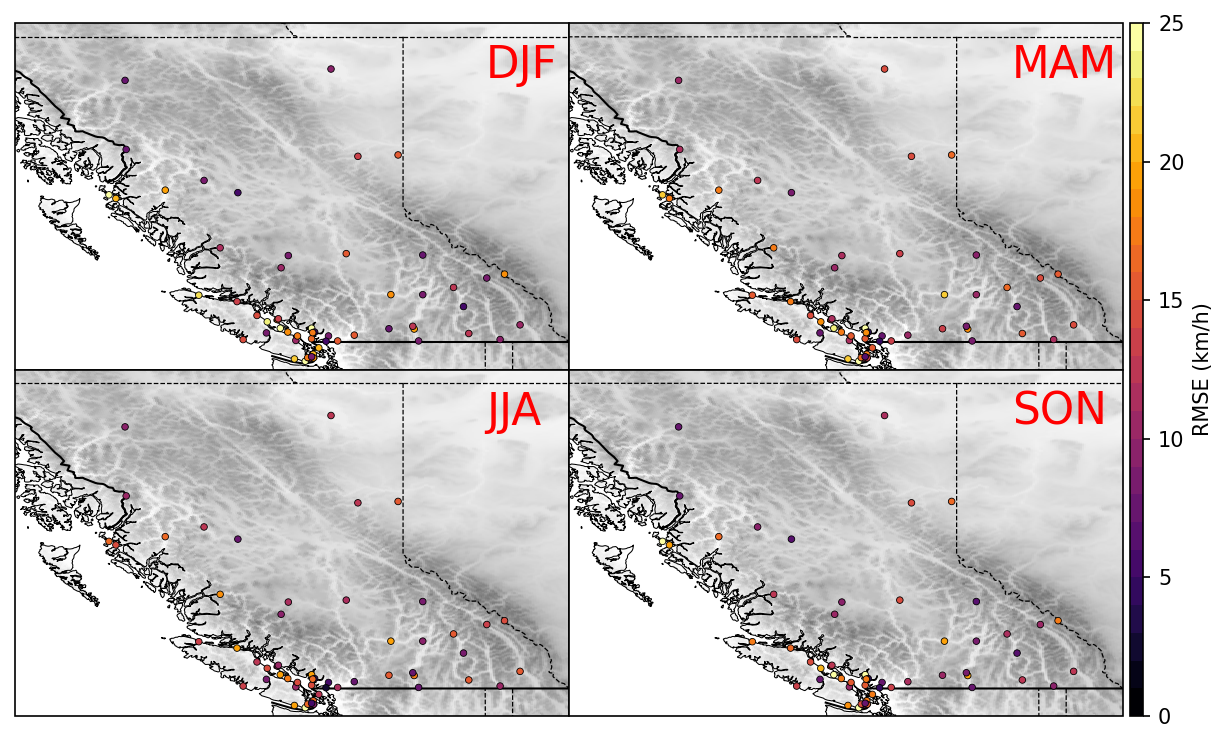

In [17]:
fig = plt.figure(figsize=(11.475,6),dpi=150)

# Create a discrete colormap with 25 steps from inferno
cmap = ListedColormap(plt.cm.inferno(np.linspace(0, 1, 25)))

lon = topography['XLONG'].squeeze()
lat = topography['XLAT'].squeeze()
hgt = topography['HGT'].squeeze()
ax0 = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree())
mesh = ax0.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax0.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax0.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax0.set_xlim(-134, -114)
ax0.set_ylim(48, 60.5)
ax0.coastlines(linewidth=0.5, zorder=2)
ax1 = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree())
mesh = ax1.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax1.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax1.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax1.set_xlim(-134, -114)
ax1.set_ylim(48, 60.5)
ax1.coastlines(linewidth=0.5, zorder=2)
ax2 = fig.add_subplot(2, 2, 3, projection=ccrs.PlateCarree())
mesh = ax2.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax2.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax2.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax2.set_xlim(-134, -114)
ax2.set_ylim(48, 60.5)
ax2.coastlines(linewidth=0.5, zorder=2)
ax3 = fig.add_subplot(2, 2, 4, projection=ccrs.PlateCarree())
mesh = ax3.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax3.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax3.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax3.set_xlim(-134, -114)
ax3.set_ylim(48, 60.5)
ax3.coastlines(linewidth=0.5, zorder=2)

lons, lats, rmses = [], [], []
for stn_coords, rmse in rmse_dict_DJF.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    rmses.append(rmse)
ax0.text(-117, 58.5, "DJF", color='red', fontsize=21)
scatter0 = ax0.scatter(
    lons, lats,
    c=rmses,
    s=10,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=25
)
lons, lats, rmses = [], [], []
for stn_coords, rmse in rmse_dict_MAM.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    rmses.append(rmse)
ax1.text(-118, 58.5, "MAM", color='red', fontsize=21)
scatter1 = ax1.scatter(
    lons, lats,
    c=rmses,
    s=10,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=25
)
lons, lats, rmses = [], [], []
for stn_coords, rmse in rmse_dict_JJA.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    rmses.append(rmse)
ax2.text(-117, 58.5, "JJA", color='red', fontsize=21)
scatter2 = ax2.scatter(
    lons, lats,
    c=rmses,
    s=10,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=25
)
lons, lats, rmses = [], [], []
for stn_coords, rmse in rmse_dict_SON.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    rmses.append(rmse)
ax3.text(-118, 58.5, "SON", color='red', fontsize=21)
scatter3 = ax3.scatter(
    lons, lats,
    c=rmses,
    s=10,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=25
)

plt.subplots_adjust(wspace=-.035, hspace=-0)
cbar = plt.colorbar(scatter0, ax=[ax0,ax1,ax2,ax3], orientation='vertical', pad=0.005, shrink=1, aspect=50)
cbar.set_label('RMSE (km/h)')
plt.show()

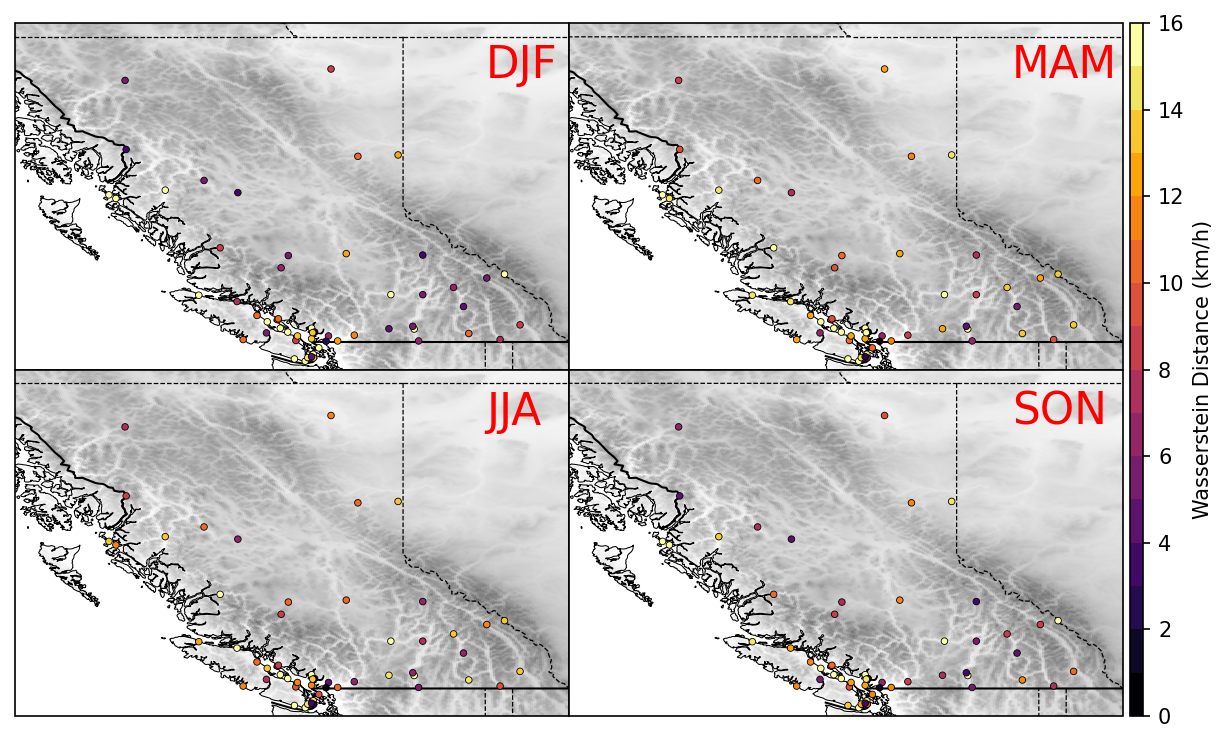

In [18]:
fig = plt.figure(figsize=(11.475,6),dpi=150)

# Create a discrete colormap with 16 steps from inferno
cmap = ListedColormap(plt.cm.inferno(np.linspace(0, 1, 16)))

lon = topography['XLONG'].squeeze()
lat = topography['XLAT'].squeeze()
hgt = topography['HGT'].squeeze()
ax0 = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree())
mesh = ax0.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax0.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax0.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax0.set_xlim(-134, -114)
ax0.set_ylim(48, 60.5)
ax0.coastlines(linewidth=0.5, zorder=2)
ax1 = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree())
mesh = ax1.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax1.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax1.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax1.set_xlim(-134, -114)
ax1.set_ylim(48, 60.5)
ax1.coastlines(linewidth=0.5, zorder=2)
ax2 = fig.add_subplot(2, 2, 3, projection=ccrs.PlateCarree())
mesh = ax2.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax2.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax2.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax2.set_xlim(-134, -114)
ax2.set_ylim(48, 60.5)
ax2.coastlines(linewidth=0.5, zorder=2)
ax3 = fig.add_subplot(2, 2, 4, projection=ccrs.PlateCarree())
mesh = ax3.pcolormesh(lon, lat, hgt, transform=ccrs.PlateCarree(), shading='auto', cmap='grey_r')
ax3.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=2)
ax3.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=2)
ax3.set_xlim(-134, -114)
ax3.set_ylim(48, 60.5)
ax3.coastlines(linewidth=0.5, zorder=2)

lons, lats, wasss = [], [], []
for stn_coords, wass in wass_dict_DJF.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    wasss.append(wass)
ax0.text(-117, 58.5, "DJF", color='red', fontsize=21)
scatter0 = ax0.scatter(
    lons, lats,
    c=wasss,
    s=10,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=16
)
lons, lats, wasss = [], [], []
for stn_coords, wass in wass_dict_MAM.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    wasss.append(wass)
ax1.text(-118, 58.5, "MAM", color='red', fontsize=21)
scatter1 = ax1.scatter(
    lons, lats,
    c=wasss,
    s=10,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=16
)
lons, lats, wasss = [], [], []
for stn_coords, wass in wass_dict_JJA.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    wasss.append(wass)
ax2.text(-117, 58.5, "JJA", color='red', fontsize=21)
scatter2 = ax2.scatter(
    lons, lats,
    c=wasss,
    s=10,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=16
)
lons, lats, wasss = [], [], []
for stn_coords, wass in wass_dict_SON.items():
    lat, lon = stn_coords
    lats.append(lat)
    lons.append(lon)
    wasss.append(wass)
ax3.text(-118, 58.5, "SON", color='red', fontsize=21)
scatter3 = ax3.scatter(
    lons, lats,
    c=wasss,
    s=10,
    cmap=cmap,
    edgecolor='k',
    linewidth=0.4,
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=3,
    vmin=0,
    vmax=16
)

plt.subplots_adjust(wspace=-.035, hspace=-0)
cbar = plt.colorbar(scatter0, ax=[ax0,ax1,ax2,ax3], orientation='vertical', pad=0.005, shrink=1, aspect=50)
cbar.set_label('Wasserstein Distance (km/h)')
plt.show()